In [1]:
!pip install kneed

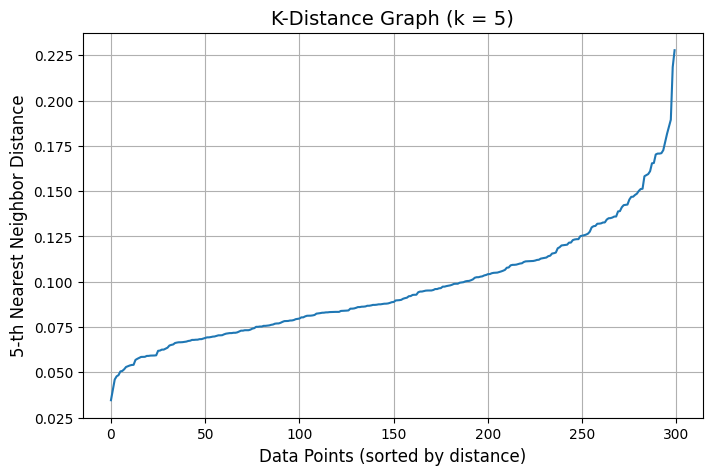

🔹 Optimal eps (from knee): 0.171


In [2]:
# =============================
# 📊 K-Distance Graph for DBSCAN
# =============================

from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator

# 1️⃣ Generate a sample dataset (you can replace with your own X)
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# 2️⃣ Compute distances to k-nearest neighbors
k = 5  # number of neighbors
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

# 3️⃣ Take the k-th nearest neighbor distance for each point
k_distances = np.sort(distances[:, k-1])  # 4th index = 5th neighbor

# 4️⃣ Plot the sorted k-distances
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Graph (k = {k})', fontsize=14)
plt.xlabel('Data Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.grid(True)
plt.show()

# 5️⃣ Find the "elbow" point automatically (optional)
knee = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')

print("🔹 Optimal eps (from knee):", round(k_distances[knee.knee], 3))
